In [12]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import lightgbm as lgb
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc as sk_auc
)

warnings.filterwarnings('ignore')
shap.initjs()

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'LightGBM     : {lgb.__version__}')
print(f'SHAP         : {shap.__version__}')

Scikit-learn : 1.8.0
LightGBM     : 4.6.0
SHAP         : 0.51.0


In [13]:
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

Python executable: c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [14]:
# Load all CSV files in the specified folder into a single DataFrame
import glob, os

CSV_FOLDER = './MachineLearningCVE'          
csv_files = glob.glob(os.path.join(CSV_FOLDER, '*.csv'))

if csv_files:
    dfs = []
    for f in csv_files:
        print(f'Loading: {f}')
        tmp = pd.read_csv(f, low_memory=False)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal rows loaded: {len(df):,}')
else:
    raise FileNotFoundError('No CSV files found. Update CSV_FOLDER path.')

df.head()

Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv

Total rows loaded: 2,830,743


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
# Standardise column names
df.columns = df.columns.str.strip()

# Auto-detect label column
LABEL_COL = 'Label'
if LABEL_COL not in df.columns:
    LABEL_COL = [c for c in df.columns if 'label' in c.lower()][0]
print(f'Label column : "{LABEL_COL}"')
print(f'Shape        : {df.shape}')

print('\nClass distribution:')
print(df[LABEL_COL].value_counts())

Label column : "Label"
Shape        : (2830743, 79)

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


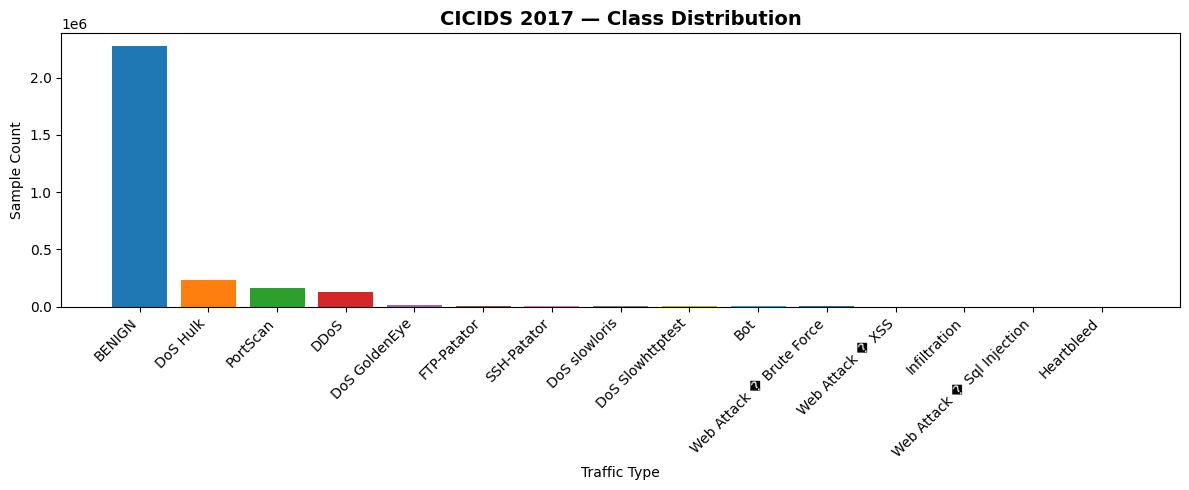

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
counts = df[LABEL_COL].value_counts()
ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors[:len(counts)])
ax.set_title('CICIDS 2017 — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Drop identifier columns
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
             'Src IP', 'Dst IP', 'src_ip', 'dst_ip']
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Replace inf / -inf with NaN 
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with > 50% missing
thresh = len(df) * 0.5
df.dropna(axis=1, thresh=thresh, inplace=True)

# Fill remaining NaNs with median for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f'Shape before dedup : {df.shape}')

# Remove duplicate records
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f'Shape after dedup  : {df.shape}  ({before - after:,} duplicates removed)')
print(f'Missing values     : {df.isnull().sum().sum()}')

Shape before dedup : (2830743, 79)
Shape after dedup  : (2522362, 79)  (308,381 duplicates removed)
Missing values     : 0


In [18]:
# Label encoding 
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))

class_names = le.classes_
n_classes   = len(class_names)
print(f'Number of classes: {n_classes}')
for i, name in enumerate(class_names):
    print(f'  {i}: {name}')

Number of classes: 15
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS


In [19]:
# Features / target 
X = df.drop(columns=[LABEL_COL, 'label_enc'])
X = X.select_dtypes(include=[np.number])
y = df['label_enc']

print(f'Features : {X.shape[1]}  |  Samples : {X.shape[0]}')

Features : 78  |  Samples : 2522362


In [20]:
# Stratified 80/20 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')

Train : (2017889, 78)  |  Test : (504473, 78)


In [21]:
# Min-Max Normalization 
scaler  = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print('Min-Max normalization applied.')
print(f'Feature range — min: {X_train.min().min():.2f}, max: {X_train.max().max():.2f}')

Min-Max normalization applied.
Feature range — min: 0.00, max: 1.00


In [ ]:
# Define LightGBM base learner with parameters
lgbm_model = lgb.LGBMClassifier(
    objective         = 'multiclass',
    metric            = 'multi_logloss',
    num_class         = n_classes,
    n_estimators      = 100, # boosting round tree 
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    is_unbalance      = True,   
    device            = 'cpu',  # Using CPU
    random_state      = 42,
    n_jobs            = 2,  # Reduced from -1 to avoid resource exhaustion
    verbose           = -1,
)
print('LightGBM base learner defined.')
print(f'LightGBM device: {lgbm_model.device}')

LightGBM base learner defined.
LightGBM device: cpu


In [23]:
# Define BaggingClassifier with DecisionTreeClassifier base learner and random subspace selection
base_dt = DecisionTreeClassifier(
    criterion         = 'gini',
    max_depth         = 10,
    min_samples_split = 20,
    min_samples_leaf  = 10,
    random_state      = 42,
)

# Random Subspace with Bootstrap for sample_weight support

bagging_model = BaggingClassifier(
    estimator          = base_dt,
    n_estimators       = 100,
    max_samples        = 0.8,
    max_features       = 0.5,   # random subspace selection (approx sqrt)
    bootstrap          = True,   # Required for sample_weight support
    bootstrap_features = False,
    n_jobs             = 2,  # Reduced from -1 to avoid resource exhaustion
    random_state       = 42,
    verbose            = 0,
)
print('Modified Bagging + DT (Random Subspace) base learner defined.')

Modified Bagging + DT (Random Subspace) base learner defined.


In [24]:
# Cross-validation setup
N_FOLDS   = 10
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# OOF arrays for training meta-learner  (shape: n_train × n_classes each)
oof_lgbm    = np.zeros((len(X_train), n_classes))
oof_bagging = np.zeros((len(X_train), n_classes))

# Test prediction accumulators (averaged over folds)
test_lgbm_accum    = np.zeros((len(X_test), n_classes))
test_bagging_accum = np.zeros((len(X_test), n_classes))

X_train_arr = X_train.values
y_train_arr = y_train.values
X_test_arr  = X_test.values

print(f'Running {N_FOLDS}-Fold Cross-Validation...\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_arr, y_train_arr), 1):
    print(f'  Fold {fold}/{N_FOLDS}', end=' ')

    X_tr, X_val = X_train_arr[tr_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[tr_idx], y_train_arr[val_idx]

    # LightGBM 
    lgbm_model.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(-1)],
    )
    oof_lgbm[val_idx]     = lgbm_model.predict_proba(X_val)
    test_lgbm_accum      += lgbm_model.predict_proba(X_test_arr)
    print('| LGBM ✓', end=' ')

    # Modified Bagging + DT 
    sw = compute_sample_weight(class_weight='balanced', y=y_tr)
    bagging_model.fit(X_tr, y_tr, sample_weight=sw)
    oof_bagging[val_idx]   = bagging_model.predict_proba(X_val)
    test_bagging_accum    += bagging_model.predict_proba(X_test_arr)
    print('| Bagging ✓')

# Average test predictions over folds
test_lgbm_avg    = test_lgbm_accum    / N_FOLDS
test_bagging_avg = test_bagging_accum / N_FOLDS

print('\nOOF generation complete.')

Running 10-Fold Cross-Validation...

  Fold 1/10 | LGBM ✓ | Bagging ✓
  Fold 2/10 | LGBM ✓ | Bagging ✓
  Fold 3/10 | LGBM ✓ | Bagging ✓
  Fold 4/10 | LGBM ✓ | Bagging ✓
  Fold 5/10 | LGBM ✓ | Bagging ✓
  Fold 6/10 | LGBM ✓ | Bagging ✓
  Fold 7/10 | LGBM ✓ | Bagging ✓
  Fold 8/10 | LGBM ✓ | Bagging ✓
  Fold 9/10 | LGBM ✓ | Bagging ✓
  Fold 10/10 | LGBM ✓ | Bagging ✓

OOF generation complete.


In [26]:
# Build meta-feature matrix 
# Concatenate OOF predictions of both base learners
M_train = np.hstack([oof_lgbm, oof_bagging])       # shape: (n_train, 2*n_classes)
M_test  = np.hstack([test_lgbm_avg, test_bagging_avg])  # shape: (n_test,  2*n_classes)

print(f'Meta-feature matrix M_train : {M_train.shape}  (n_train × 2k)')
print(f'Meta-feature matrix M_test  : {M_test.shape}   (n_test  × 2k)')

Meta-feature matrix M_train : (2017889, 30)  (n_train × 2k)
Meta-feature matrix M_test  : (504473, 30)   (n_test  × 2k)


In [28]:
# Train Logistic Regression meta-learner on OOF predictions
meta_learner = LogisticRegression(
    max_iter      = 1000,
    random_state  = 42,
    class_weight  = 'balanced',
    solver        = 'lbfgs',
    n_jobs        = -1,
)

meta_learner.fit(M_train, y_train_arr)
print('Logistic Regression meta-learner trained on OOF predictions.')

Logistic Regression meta-learner trained on OOF predictions.


In [29]:
# Final inference — meta-learner on test meta-features 
y_pred      = meta_learner.predict(M_test)
y_pred_prob = meta_learner.predict_proba(M_test)

print('Final stacked ensemble predictions generated.')

Final stacked ensemble predictions generated.


In [30]:
# Evaluation metrics
acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_test, y_pred, average='weighted', zero_division=0)
ll   = log_loss       (y_test, y_pred_prob)
auc  = roc_auc_score  (y_test, y_pred_prob, multi_class='ovr', average='weighted')


print('    STACKED ENSEMBLE — EVALUATION METRICS')
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (w-avg) : {prec:.4f}')
print(f'  Recall    (w-avg) : {rec:.4f}')
print(f'  F1-Score  (w-avg) : {f1:.4f}')
print(f'  AUC-ROC   (w-avg) : {auc:.4f}')
print(f'  Log Loss          : {ll:.4f}')

    STACKED ENSEMBLE — EVALUATION METRICS
  Accuracy          : 0.9888
  Precision (w-avg) : 0.9982
  Recall    (w-avg) : 0.9888
  F1-Score  (w-avg) : 0.9931
  AUC-ROC   (w-avg) : 0.9999
  Log Loss          : 0.0410


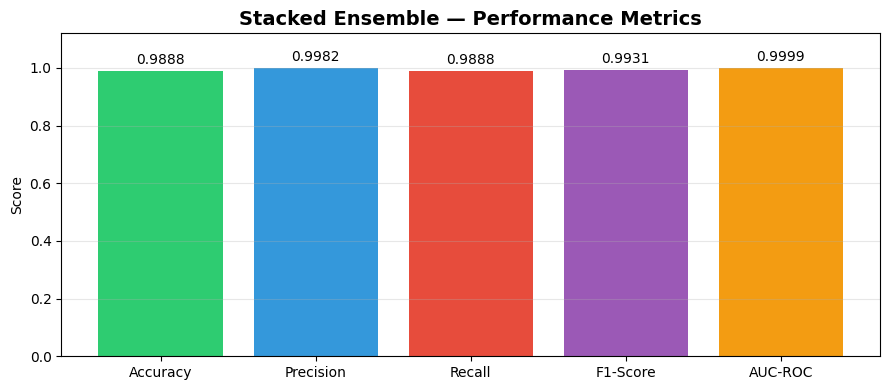

Log Loss: 0.0410  (lower is better, not plotted above)


In [ ]:
# Metrics bar chart
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'AUC-ROC'  : auc,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12'])
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_title('Stacked Ensemble — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Log Loss: {ll:.4f}  (lower is better, not plotted above)')

In [32]:
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    419297
                       Bot       0.12      1.00      0.21       391
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      1.00      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34570
          DoS Slowhttptest       0.88      1.00      0.94      1046
             DoS slowloris       1.00      1.00      1.00      1077
               FTP-Patator       1.00      1.00      1.00      1187
                Heartbleed       0.15      1.00      0.27         2
              Infiltration       0.15      1.00      0.26         7
                  PortScan       0.99      1.00      0.99     18164
               SSH-Patator       0.98      1.00      0.99       644
  Web Attack � Brute Force       0.88      0.45      0.59       294
Web Attack � Sql Injection       0.01      1.00

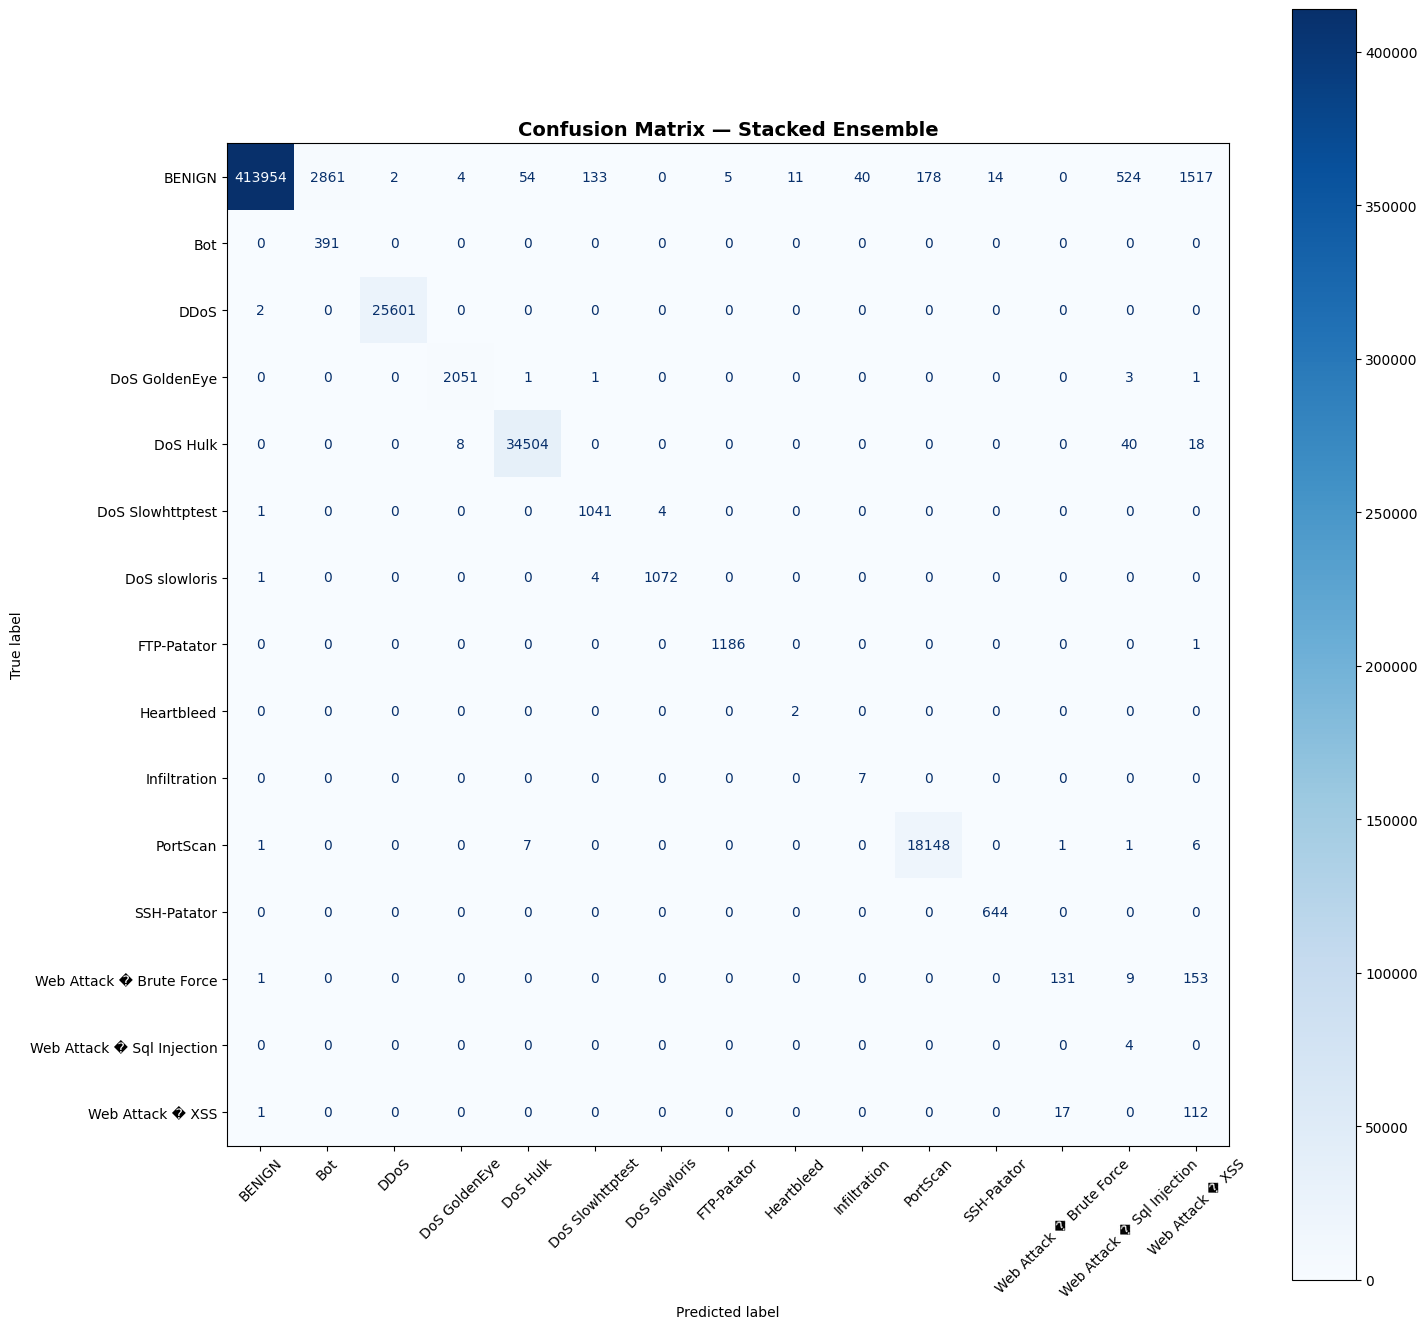

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes - 1)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix — Stacked Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

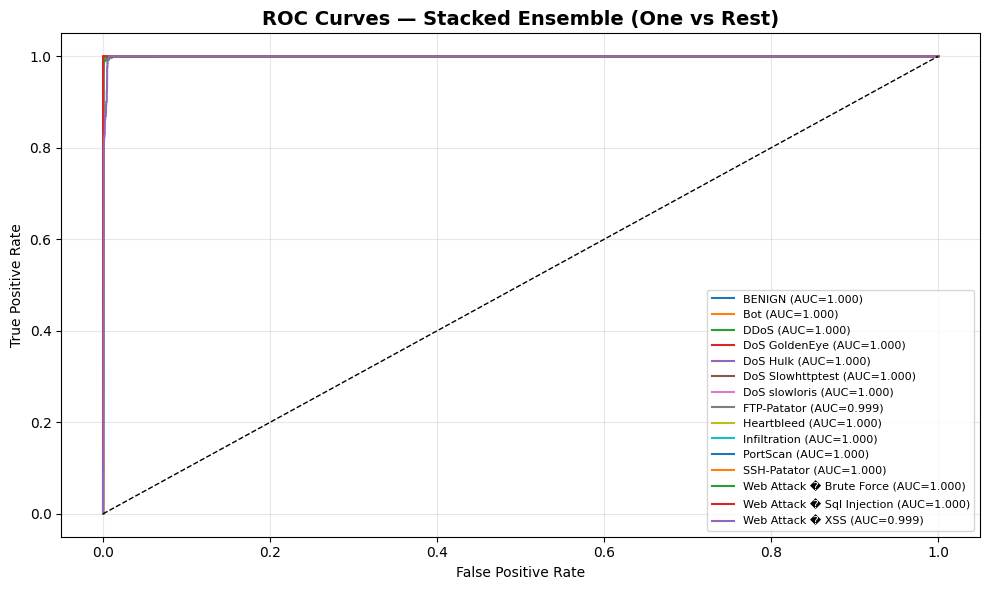

In [ ]:
# ROC Curves (One vs Rest)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.tab10.colors

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color=colors[i % 10],
            label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC Curves — Stacked Ensemble (One vs Rest)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()